|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Weight inits and investigations<h1>|
|<h2>Lecture:</h2>|<h1><b>A surprising demonstration of weight initializations<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [3]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [5]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


In [6]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm ).float()
labelsT = torch.tensor( labels ).long()

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

# Create the DL model

In [7]:
# create a class for the model
def createTheMNISTNet():

  class mnistNet(nn.Module):
    def __init__(self):
      super().__init__()

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)

  # create the model instance
  net = mnistNet()

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)

  return net,lossfun,optimizer

# Explore the weights

In [8]:
tmpnet = createTheMNISTNet()[0]
print(tmpnet)

print('\n\nWeights for layer fc1:')
print(tmpnet.fc1.weight.data)

mnistNet(
  (input): Linear(in_features=784, out_features=64, bias=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=10, bias=True)
)


Weights for layer fc1:
tensor([[-0.0899,  0.0589, -0.0244,  ..., -0.0853,  0.0728, -0.1204],
        [-0.0664, -0.1020,  0.1240,  ...,  0.0830, -0.0378, -0.1050],
        [ 0.0007,  0.0422,  0.0017,  ...,  0.0239, -0.0418,  0.0116],
        ...,
        [-0.0898, -0.0728,  0.1182,  ..., -0.1050,  0.1183,  0.0513],
        [-0.0513, -0.0261, -0.0539,  ...,  0.1158, -0.0878,  0.1241],
        [ 0.0853, -0.0987, -0.0159,  ...,  0.0260, -0.0155, -0.0246]])


# Create a function that trains the model

In [9]:
def function2trainTheModel(net,lossfun,optimizer):

  # number of epochs
  numepochs = 10

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):

    # switch on train mode
    net.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,net

# Run the model and show the results!

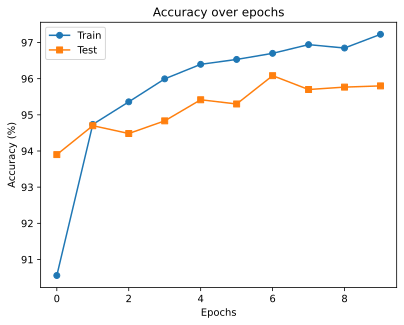

In [10]:
# Run the model without changing the weights; this will be the baseline performance.
# Notice the model creation is outside the function2train
net_base,lossfun,optimizer = createTheMNISTNet()
trainAcc_base,testAcc_base,losses,net_base = function2trainTheModel(net_base,lossfun,optimizer)

# plot the results
plt.plot(range(len(trainAcc_base)),trainAcc_base,'o-', range(len(testAcc_base)),testAcc_base ,'s-')
plt.legend(['Train','Test'])
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

# Set all the weights of layer 1 to zero

In [11]:
# Change the weights before training
net_zero,lossfun,optimizer = createTheMNISTNet()

# set to zeros
net_zero.fc1.weight.data = torch.zeros_like( net_zero.fc1.weight )

# confirm
net_zero.fc1.weight.data

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

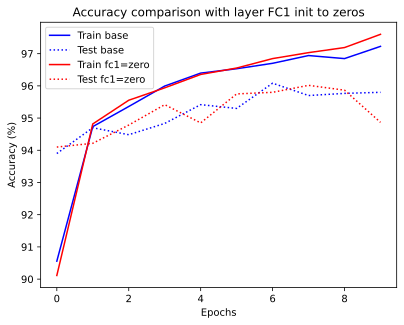

In [12]:
# run the model and show the results
trainAcc_zero,testAcc_zero,losses,net_zero = function2trainTheModel(net_zero,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_zero)),trainAcc_zero,'r-', range(len(testAcc_zero)),testAcc_zero ,'r:')
plt.legend(['Train base','Test base','Train fc1=zero','Test fc1=zero'])
plt.title('Accuracy comparison with layer FC1 init to zeros')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

tensor([[-0.0605, -1.9726,  0.8845,  ..., -0.8571,  0.2012,  0.0161],
        [-0.2860, -0.9036, -0.6686,  ..., -0.5484, -0.1347,  0.0157],
        [-1.0429,  0.6148, -0.0228,  ...,  0.8574, -0.6691,  0.0747],
        ...,
        [-0.9673, -0.5677, -0.7150,  ..., -0.6283,  0.4144, -0.0120],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])


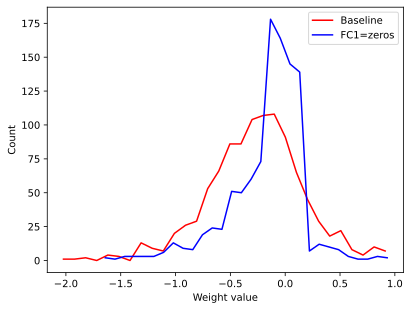

In [13]:
# Are the weights still zeros?
print(net_zero.fc1.weight.data)

# show the distributions in a histogram
y,x = np.histogram(net_base.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_zero.fc2.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'b',label='FC1=zeros')

plt.legend()
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.show()

# Let's repeat the experiment with all learnable parameters set to zero

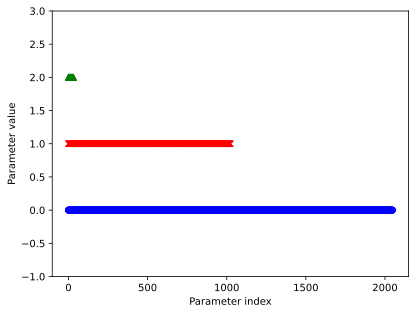

In [14]:
# Change the weights before training
net_allzero,lossfun,optimizer = createTheMNISTNet()

# loop over parameters and set them all to zeros
for p in net_allzero.named_parameters():
  p[1].data = torch.zeros_like( p[1].data )


# and confirm for a few select parameters (y-axis offset for visibility)
plt.plot(0+net_allzero.fc1.weight.data.flatten(),'bo')
plt.plot(1+net_allzero.fc2.weight.data.flatten(),'rx')
plt.plot(2+net_allzero.fc1.bias.data.flatten(),'g^')
plt.xlabel('Parameter index')
plt.ylim([-1,3])
plt.ylabel('Parameter value')
plt.show()

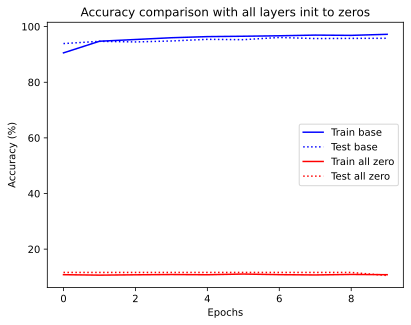

In [15]:
# run the model and show the results
trainAcc_allzero,testAcc_allzero,losses,net_allzero = function2trainTheModel(net_allzero,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_allzero)),trainAcc_allzero,'r-', range(len(testAcc_allzero)),testAcc_allzero ,'r:')
plt.legend(['Train base','Test base','Train all zero','Test all zero'])
plt.title('Accuracy comparison with all layers init to zeros')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

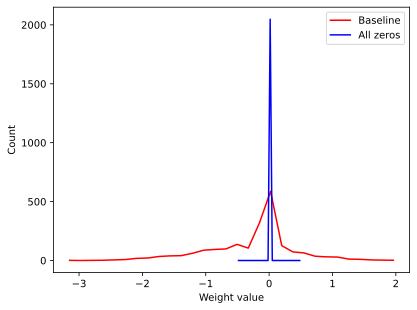

In [16]:
# show the distributions in a histogram
y,x = np.histogram(net_base.fc1.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_allzero.fc1.weight.data.flatten(),30)
plt.plot((x[1:]+x[:-1])/2,y,'b',label='All zeros')

plt.legend()
plt.xlabel('Weight value')
plt.ylabel('Count')
plt.show()

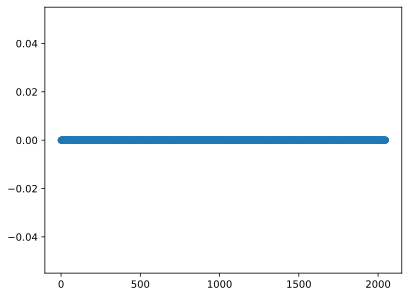

In [17]:
# woah, not even a single non-zero weight value?!?!!?!!??
plt.plot(net_allzero.fc1.weight.data.flatten(),'o');

# Maybe zero is problematic. What about initializing to 1's?

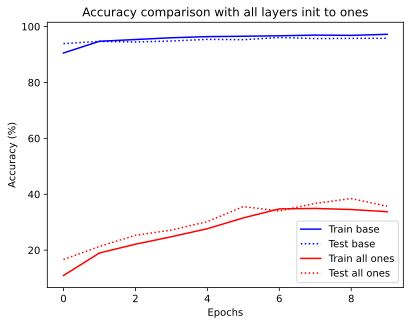

In [18]:
# Change the weights before training
net_allone,lossfun,optimizer = createTheMNISTNet()
for p in net_allone.named_parameters():
  p[1].data = torch.zeros_like( p[1].data ) + 1
  #p[1].data = torch.zeros( p[1].data.shape ) + 1 # equivalent to the previous line!


# run the model and show the results
trainAcc_allone,testAcc_allone,losses,net_allone = function2trainTheModel(net_allone,lossfun,optimizer)

plt.plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
plt.plot(range(len(trainAcc_allone)),trainAcc_allone,'r-', range(len(testAcc_allone)),testAcc_allone ,'r:')
plt.legend(['Train base','Test base','Train all ones','Test all ones'])
plt.title('Accuracy comparison with all layers init to ones')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()

# Additional explorations

In [19]:
# 1) You saw that initializing only the weights in fc1 still allowed for good performance, while having all weights be
#    the same value led to HORRIBLE performance. Try setting all weights to ones and all biases to zeros (across all
#    layers). Does that allow for learning? If so, how does it compare to the baseline model performance?
#
# 2) Now try setting all the weights from all layers to zeros, but leave the bias terms with their initial random values.
#
# 3) Finally, the opposite of #2: Set all bias terms to zero and leave the weights random. Make a plot of test accuracy
#    performance for the baseline model, weights=0, and biases=0.
#

In [ ]:
# 1) You saw that initializing only the weights in fc1 still allowed for good performance, while having all weights be
#    the same value led to HORRIBLE performance. Try setting all weights to ones and all biases to zeros (across all
#    layers). Does that allow for learning? If so, how does it compare to the baseline model performance?
# Answer: The model learns. The modelperformance is wrose at atound 35% accuracy, while baseline provides around 95% accuracy. 

# Change the weights before training
net_all_ones_biases_zeros,lossfun,optimizer = createTheMNISTNet()

# loop over parameters and set them all to zeros
for p in net_all_ones_biases_zeros.named_parameters():
    p[1].data = torch.zeros_like( p[1].data ) if 'bias' in p[0] else torch.ones_like( p[1].data )
    
# run the model and show the results
trainAcc_all_ones_biases_zeros,testAcc_all_ones_biases_zeros,losses,net_all_ones_biases_zeros = function2trainTheModel(
        net_all_ones_biases_zeros,lossfun,optimizer)

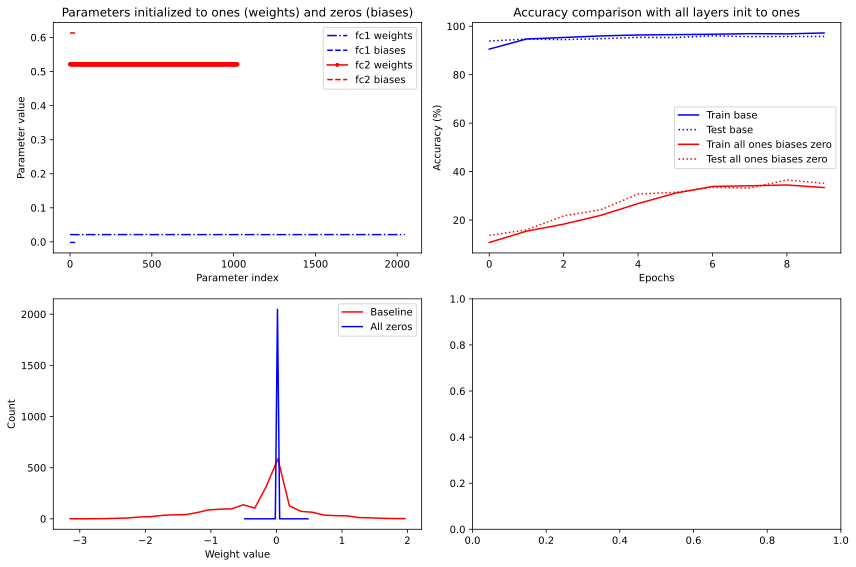

In [51]:
# and confirm for a few select parameters (y-axis offset for visibility)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,0].plot(0+net_all_ones_biases_zeros.fc1.weight.data.flatten(),'b-.', label='fc1 weights')
axs[0,0].plot(0+net_all_ones_biases_zeros.fc1.bias.data.flatten(),'b--', label='fc1 biases')
axs[0,0].plot(0.5+net_all_ones_biases_zeros.fc2.weight.data.flatten(),'r.-', label='fc2 weights')
axs[0,0].plot(0.5+net_all_ones_biases_zeros.fc2.bias.data.flatten(),'r--', label='fc2 biases')
axs[0,0].set_xlabel('Parameter index')
# axs[0,0].set_ylim([-1,3])
axs[0,0].set_ylabel('Parameter value')
axs[0,0].legend()

axs[0,1].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,1].plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
axs[0,1].plot(range(len(trainAcc_all_ones_biases_zeros)),trainAcc_all_ones_biases_zeros,'r-',
         range(len(testAcc_all_ones_biases_zeros)),testAcc_all_ones_biases_zeros ,'r:')
axs[0,1].legend(['Train base','Test base','Train all ones biases zero','Test all ones biases zero'])
axs[0,1].set_title('Accuracy comparison with all layers init to ones')
axs[0,1].set_xlabel('Epochs')
axs[0,1].set_ylabel('Accuracy (%)')

# show the distributions in a histogram
y,x = np.histogram(net_base.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_allzero.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'b',label='All zeros')

axs[1,0].legend()
axs[1,0].set_xlabel('Weight value')
axs[1,0].set_ylabel('Count')

fig.tight_layout()
plt.show()

In [ ]:
# 2) Now try setting all the weights from all layers to zeros, but leave the bias terms with their initial random values.
# The model learns and reaches about 92% accuracy, while baseline reaches around 95% accuracy in this particluar test. 

# Change the weights before training
net_all_zeros_biases_random,lossfun,optimizer = createTheMNISTNet()

# loop over parameters and set them all to zeros
for p in net_all_zeros_biases_random.named_parameters():
    if 'bias' not in p[0]:
        p[1].data = torch.zeros_like( p[1].data )
    
# run the model and show the results
trainAcc_all_zeros_biases_random,testAcc_all_zeros_biases_random,losses,net_all_zeros_biases_random = function2trainTheModel(
        net_all_zeros_biases_random,lossfun,optimizer)

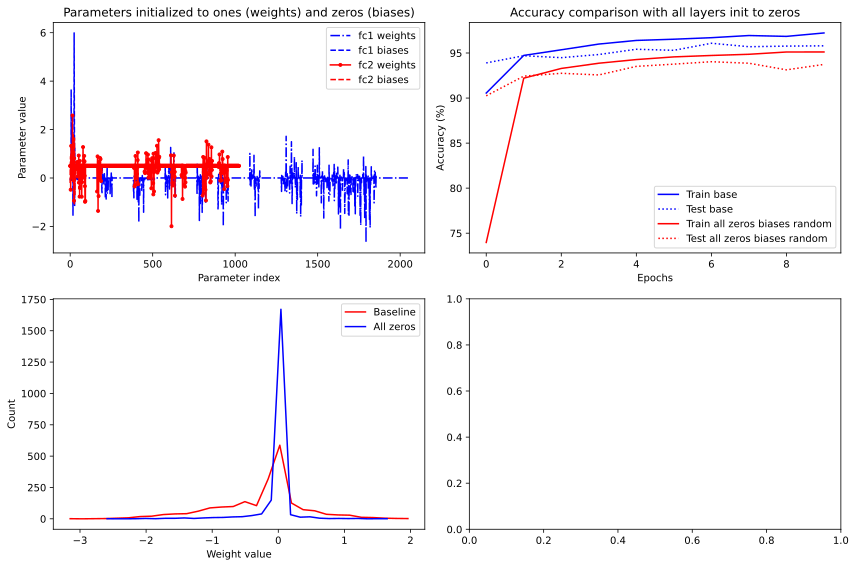

In [53]:
# and confirm for a few select parameters (y-axis offset for visibility)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,0].plot(0+net_all_zeros_biases_random.fc1.weight.data.flatten(),'b-.', label='fc1 weights')
axs[0,0].plot(0+net_all_zeros_biases_random.fc1.bias.data.flatten(),'b--', label='fc1 biases')
axs[0,0].plot(0.5+net_all_zeros_biases_random.fc2.weight.data.flatten(),'r.-', label='fc2 weights')
axs[0,0].plot(0.5+net_all_zeros_biases_random.fc2.bias.data.flatten(),'r--', label='fc2 biases')
axs[0,0].set_xlabel('Parameter index')
# axs[0,0].set_ylim([-1,3])
axs[0,0].set_ylabel('Parameter value')
axs[0,0].legend()

axs[0,1].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,1].plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
axs[0,1].plot(range(len(trainAcc_all_zeros_biases_random)),trainAcc_all_zeros_biases_random,'r-',
         range(len(testAcc_all_zeros_biases_random)),testAcc_all_zeros_biases_random ,'r:')
axs[0,1].legend(['Train base','Test base','Train all zeros biases random','Test all zeros biases random'])
axs[0,1].set_title('Accuracy comparison with all layers init to zeros')
axs[0,1].set_xlabel('Epochs')
axs[0,1].set_ylabel('Accuracy (%)')

# show the distributions in a histogram
y,x = np.histogram(net_base.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_all_zeros_biases_random.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'b',label='All zeros')

axs[1,0].legend()
axs[1,0].set_xlabel('Weight value')
axs[1,0].set_ylabel('Count')

fig.tight_layout()
plt.show()

In [ ]:
# 3) Finally, the opposite of #2: Set all bias terms to zero and leave the weights random. Make a plot of test accuracy
#    performance for the baseline model, weights=0, and biases=0.
# Answer: The model learns and reaches about 94% accuracy, while baseline reaches around 95% accuracy in this particluar test.
#         Thus the models could be considered comparable to baseline in terms of performance.

# Change the weights before training
net_all_biases_zeros,lossfun,optimizer = createTheMNISTNet()

# loop over parameters and set them all to zeros
for p in net_all_biases_zeros.named_parameters():
    if 'bias' in p[0]:
        p[1].data = torch.zeros_like( p[1].data )
    
# run the model and show the results
trainAcc_all_biases_zeros,testAcc_all_biases_zeros,losses,net_all_biases_zeros = function2trainTheModel(
        net_all_biases_zeros,lossfun,optimizer)

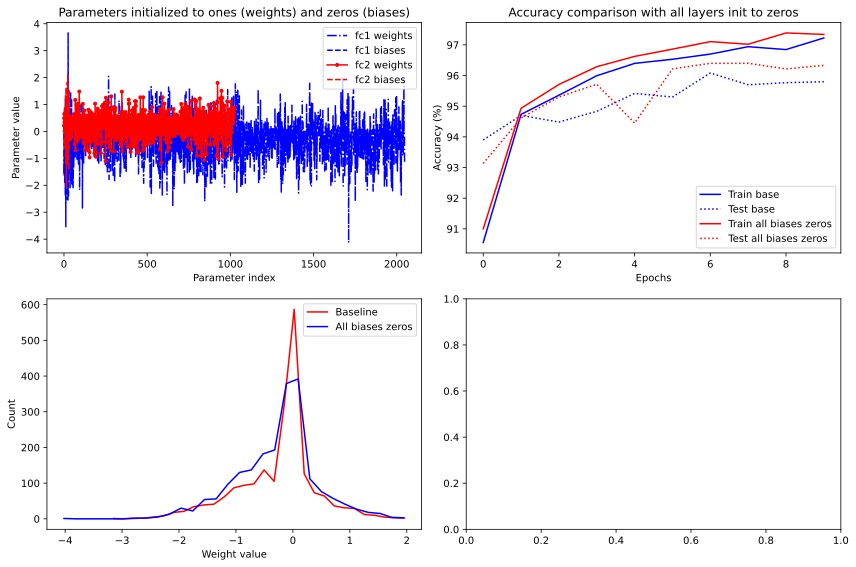

In [55]:
# and confirm for a few select parameters (y-axis offset for visibility)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,0].plot(0+net_all_biases_zeros.fc1.weight.data.flatten(),'b-.', label='fc1 weights')
axs[0,0].plot(0+net_all_biases_zeros.fc1.bias.data.flatten(),'b--', label='fc1 biases')
axs[0,0].plot(0.5+net_all_biases_zeros.fc2.weight.data.flatten(),'r.-', label='fc2 weights')
axs[0,0].plot(0.5+net_all_biases_zeros.fc2.bias.data.flatten(),'r--', label='fc2 biases')
axs[0,0].set_xlabel('Parameter index')
# axs[0,0].set_ylim([-1,3])
axs[0,0].set_ylabel('Parameter value')
axs[0,0].legend()

axs[0,1].set_title('Parameters initialized to ones (weights) and zeros (biases)')
axs[0,1].plot(range(len(trainAcc_base)),trainAcc_base,'b-', range(len(testAcc_base)),testAcc_base ,'b:')
axs[0,1].plot(range(len(trainAcc_all_biases_zeros)),trainAcc_all_biases_zeros,'r-',
         range(len(testAcc_all_biases_zeros)),testAcc_all_biases_zeros ,'r:')
axs[0,1].legend(['Train base','Test base','Train all biases zeros','Test all biases zeros'])
axs[0,1].set_title('Accuracy comparison with all layers init to zeros')
axs[0,1].set_xlabel('Epochs')
axs[0,1].set_ylabel('Accuracy (%)')

# show the distributions in a histogram
y,x = np.histogram(net_base.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'r',label='Baseline')

y,x = np.histogram(net_all_biases_zeros.fc1.weight.data.flatten(),30)
axs[1,0].plot((x[1:]+x[:-1])/2,y,'b',label='All biases zeros')

axs[1,0].legend()
axs[1,0].set_xlabel('Weight value')
axs[1,0].set_ylabel('Count')

fig.tight_layout()
plt.show()